✅ Data Loaded Successfully!
Train Shape: (1460, 81)
Test Shape: (1459, 80)

Missing Values (%):
Id                0.0
MSSubClass        0.0
MSZoning          0.0
LotFrontage      17.7
LotArea           0.0
                 ... 
MoSold            0.0
YrSold            0.0
SaleType          0.0
SaleCondition     0.0
SalePrice         0.0
Length: 81, dtype: float64


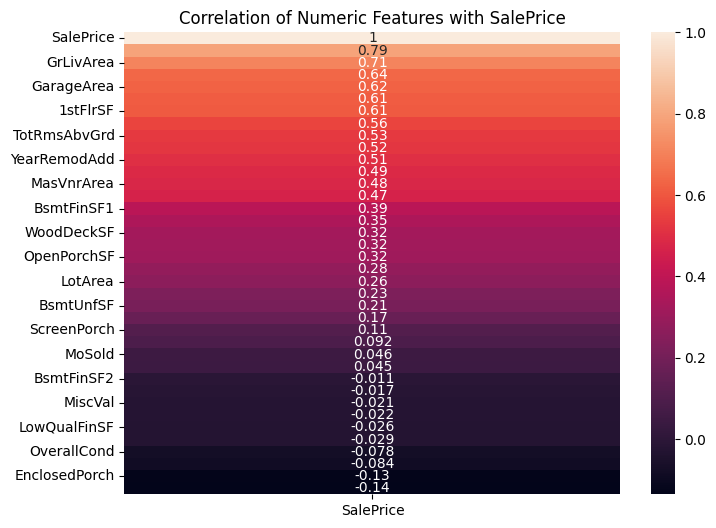

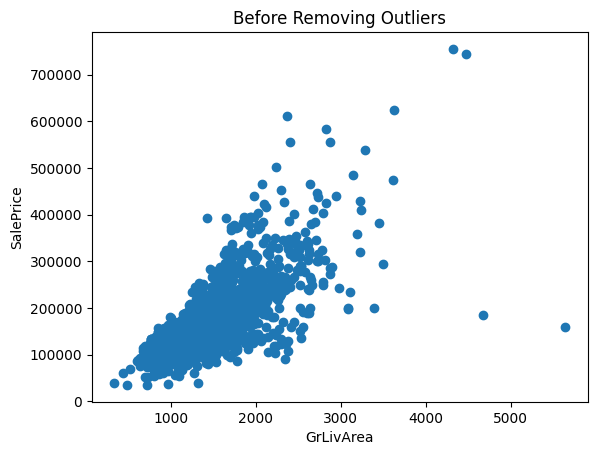

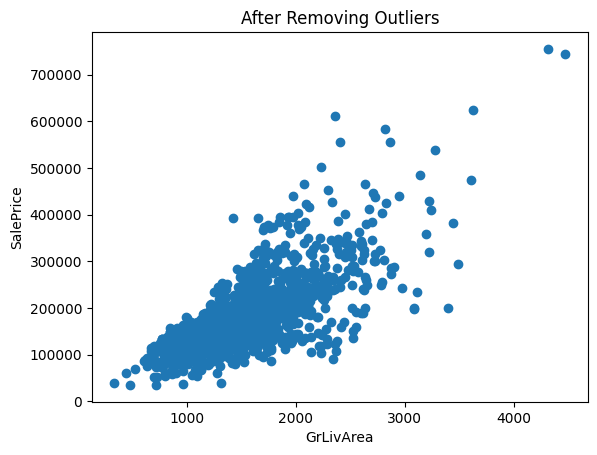

✅ Feature engineering complete!
X_train shape: (1458, 287)
X_test shape: (1459, 287)
Linear Regression RMSE (train): 19442.03
XGBoost RMSE (train): 12939.38

Mean CV RMSE: 23081.12

✅ Submission file created: submission.csv


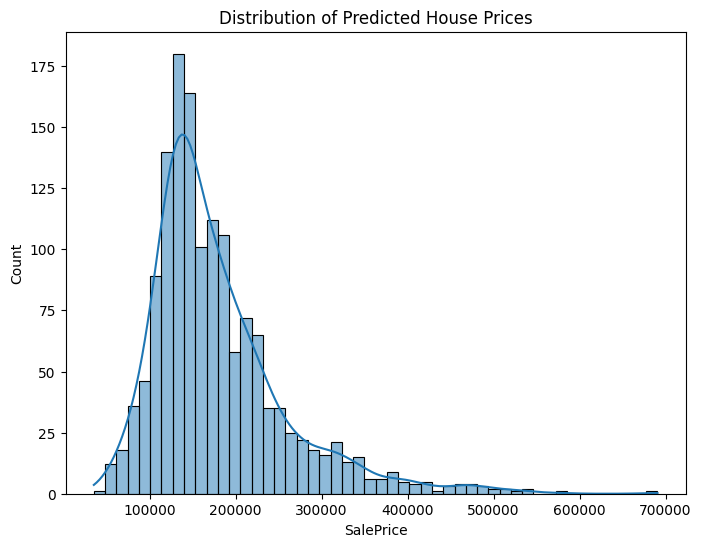

 Model trained and predictions generated successfully.


In [ ]:
# ===============================================================
# 🏡 HOUSE PRICE PREDICTION — Kaggle Challenge (Simplified Version)
# Dataset: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
# ===============================================================

# ========== STEP 1: IMPORT LIBRARIES ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# ========== STEP 2: LOAD DATA ==========
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")


print("✅ Data Loaded Successfully!")
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

# ========== STEP 3: BASIC EDA ==========
print("\nMissing Values (%):")
print(train.isnull().mean().round(3) * 100)

# Simple correlation check
plt.figure(figsize=(8,6))
sns.heatmap(train.corr(numeric_only=True)[['SalePrice']].sort_values(by='SalePrice', ascending=False), annot=True)
plt.title("Correlation of Numeric Features with SalePrice")
plt.show()

# ========== STEP 4: OUTLIER REMOVAL ==========
plt.scatter(train.GrLivArea, train.SalePrice)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Before Removing Outliers")
plt.show()

# Removing large GrLivArea but low SalePrice outliers
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)

plt.scatter(train.GrLivArea, train.SalePrice)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("After Removing Outliers")
plt.show()

# ========== STEP 5: FEATURE ENGINEERING ==========
# Combine train & test for consistent encoding
train_labels = train['SalePrice']
all_data = pd.concat([train.drop(['SalePrice'], axis=1), test], axis=0)

# Fill missing numerical features with median
num_features = all_data.select_dtypes(exclude='object').columns
all_data[num_features] = all_data[num_features].fillna(all_data[num_features].median())

# Fill missing categorical with mode
cat_features = all_data.select_dtypes(include='object').columns
all_data[cat_features] = all_data[cat_features].fillna(all_data[cat_features].mode().iloc[0])

# One-hot encoding
all_data = pd.get_dummies(all_data)

# Split back
X_train = all_data[:len(train)]
X_test = all_data[len(train):]
y_train = train_labels

print("✅ Feature engineering complete!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# ========== STEP 6: TRAIN MODELS ==========
# --- Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_pred = lin_reg.predict(X_train)
lin_rmse = np.sqrt(mean_squared_error(y_train, lin_pred))
print(f"Linear Regression RMSE (train): {lin_rmse:.2f}")

# --- XGBoost Regression ---
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_train)
xgb_rmse = np.sqrt(mean_squared_error(y_train, xgb_pred))
print(f"XGBoost RMSE (train): {xgb_rmse:.2f}")

# ========== STEP 7: CROSS VALIDATION ==========
cv_score = np.sqrt(-cross_val_score(xgb, X_train, y_train, scoring="neg_mean_squared_error", cv=5))
print(f"\nMean CV RMSE: {cv_score.mean():.2f}")

# ========== STEP 8: PREDICT ON TEST DATA ==========
preds = xgb.predict(X_test)
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": preds})
submission.to_csv("submission.csv", index=False)

print("\n✅ Submission file created: submission.csv")

# ========== STEP 9: VISUALIZE PREDICTIONS ==========
plt.figure(figsize=(8,6))
sns.histplot(submission["SalePrice"], bins=50, kde=True)
plt.title("Distribution of Predicted House Prices")
plt.show()

print(" Model trained and predictions generated successfully.")
